In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\dodos\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
## Open the dataset and check the correct opening

df = pd.read_csv("swiss_communes_ml_ready.csv")
df.head()

,bfs_nr,commune_ofs,canton,join_key,premium_region,log_pop_density,pop_density_2024,is_urban,pct_hh_1p,pct_hh_2p,...,median_premium_2026,std_premium_2026,p10_premium_2026,p90_premium_2026,iqr_premium_2026,n_insurers_2026,premium_increase_pct,n_insurers_change,sa_estimated,sa_count_est
0,1,Aeugst am Albis,ZH,ZH_H3,3,5.534180,252.2,0.0,28.9,38.2,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0
1,2,Affoltern am Albis,ZH,ZH_H3,3,7.104473,1216.4,1.0,36.3,32.9,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0
2,3,Bonstetten,ZH,ZH_H3,3,6.646131,768.8,0.0,30.0,33.5,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0
3,4,Hausen am Albis,ZH,ZH_H3,3,5.675040,290.5,0.0,30.8,35.2,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0
4,5,Hedingen,ZH,ZH_H3,3,6.419832,612.9,0.0,28.9,35.1,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bfs_nr                   1503 non-null   int64  
 1   commune_ofs              1503 non-null   str    
 2   canton                   1503 non-null   str    
 3   join_key                 1503 non-null   str    
 4   premium_region           1503 non-null   int64  
 5   log_pop_density          1503 non-null   float64
 6   pop_density_2024         1503 non-null   float64
 7   is_urban                 1503 non-null   float64
 8   pct_hh_1p                1503 non-null   float64
 9   pct_hh_2p                1503 non-null   float64
 10  pct_hh_3p                1503 non-null   float64
 11  pct_hh_4p                1503 non-null   float64
 12  pct_hh_5p_plus           1503 non-null   float64
 13  pct_large_hh             1503 non-null   float64
 14  pct_small_hh             1503 non-n

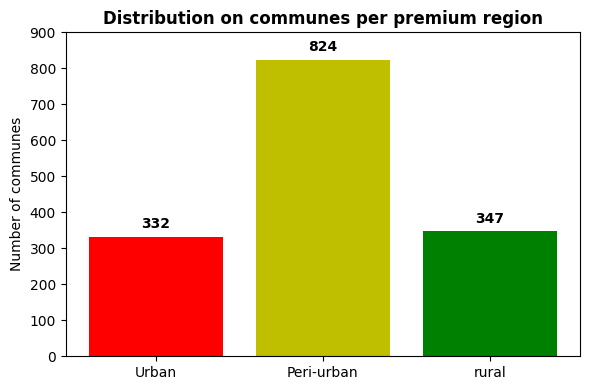

In [22]:
## SHOWING CLASS UNBALANCE:

LABELS = {1: 'Urban', 2: 'Peri-urban', 3: 'rural'}
colors = ['r', 'y', 'g']

fig, ax = plt.subplots(figsize=(6,4))
counts = df["premium_region"].value_counts().sort_index()
bars = ax.bar([LABELS[i] for i in counts.index], counts.values, color=colors)
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("Distribution on communes per premium region", fontweight="heavy")
ax.set_ylabel("Number of communes")
ax.set_ylim(0, 900)
plt.tight_layout()

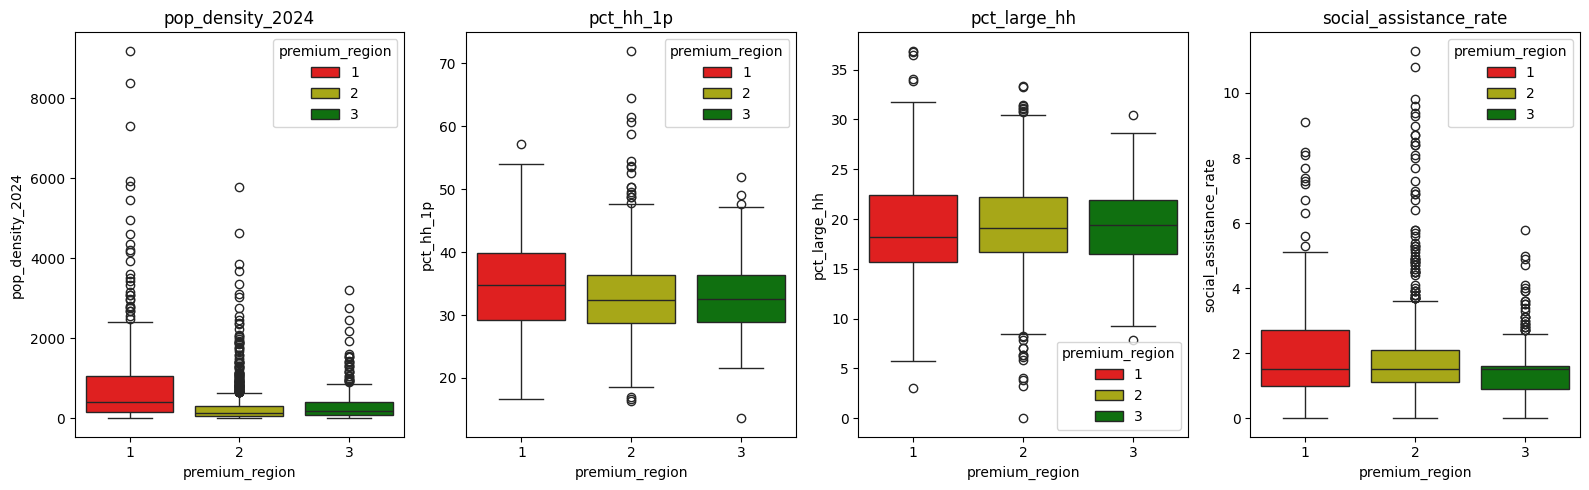

In [26]:
## BOXPLOTS SOCIO-DEMOGRAPHIQUE FEATURES VS PREMIUM REGION

sd_features = ["pop_density_2024", "pct_hh_1p", "pct_large_hh", "social_assistance_rate"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i in range(len(sd_features)):
    sns.boxplot(data=df, x="premium_region", hue="premium_region", y=sd_features[i], ax=axes[i], palette=colors)
    axes[i].set_title(sd_features[i])

plt.tight_layout()

## Anomaly Detection: Rule-based misclassification candidates

Before running any ML model, we can already identify suspicious communes using a simple rule based on population density.

The logic is the following:
- We take the 75th percentile of density among Region 3 (rural) communes → this is the "maximum typical rural density". Any Region 1 (urban) commune below this threshold is less dense than 75% of rural communes → it is paying urban prices without having an urban profile

- We take the 25th percentile of density among Region 1 (urban) communes → this is the "minimum typical urban density". Any Region 3 (rural) commune above this threshold is denser than 75% of urban communes → it is paying rural prices without having a rural profile

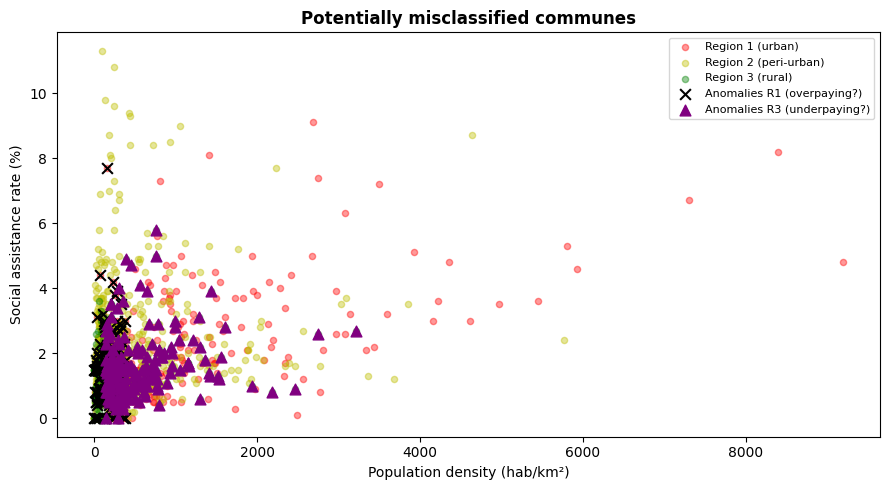

In [29]:
# POTENTIAL MISCLASSIFICATION

r3_density_p75 = df[df['premium_region'] == 3]['pop_density_2024'].quantile(0.75)
r1_density_p25 = df[df['premium_region'] == 1]['pop_density_2024'].quantile(0.25)

anomali_r1 = df[(df['premium_region'] == 1) & (df['pop_density_2024'] < r3_density_p75)]
anomali_r3 = df[(df['premium_region'] == 3) & (df['pop_density_2024'] > r1_density_p25)]

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['r', 'y', 'g']
labels = ['Region 1 (urban)', 'Region 2 (peri-urban)', 'Region 3 (rural)']

for i, r in enumerate([1, 2, 3]):
    sub = df[df['premium_region'] == r]
    ax.scatter(sub['pop_density_2024'], sub['social_assistance_rate'],
               color=colors[i], alpha=0.4, s=20, label=labels[i])

ax.scatter(anomali_r1['pop_density_2024'], anomali_r1['social_assistance_rate'],
           color='black', marker='x', s=60, linewidths=1.5, label='Anomalies R1 (overpaying?)')
ax.scatter(anomali_r3['pop_density_2024'], anomali_r3['social_assistance_rate'],
           color='purple', marker='^', s=60, label='Anomalies R3 (underpaying?)')

ax.set_xlabel('Population density (hab/km²)')
ax.set_ylabel('Social assistance rate (%)')
ax.set_title('Potentially misclassified communes', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('eda_anomalies.png', dpi=150)

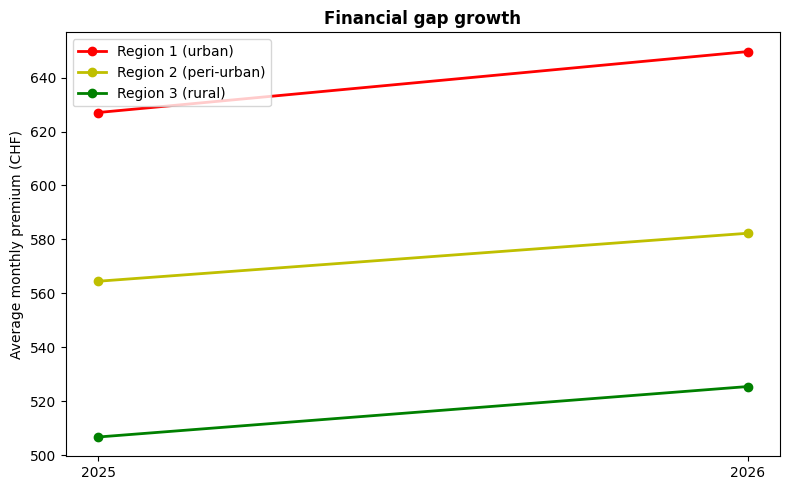

In [32]:
gap = df.groupby('premium_region')[['avg_premium_2025', 'avg_premium_2026']].mean()

fig, ax = plt.subplots(figsize=(8, 5))

x = [0, 1]  # 2025 and 2026

for i, r in enumerate([1, 2, 3]):
    ax.plot(x, [gap.loc[r, 'avg_premium_2025'], gap.loc[r, 'avg_premium_2026']],
            color=colors[i], marker='o', linewidth=2, label=labels[i])

ax.set_xticks([0, 1])
ax.set_xticklabels(['2025', '2026'])
ax.set_ylabel('Average monthly premium (CHF)')
ax.set_title('Financial gap growth', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150)

## MULTICOLLINEARITY

From the correlation heatmap, we can see that some variable are correlated between each others, making the dataset a little bit redundant. Instead of keeping all the variables, some can be eliminated from the dataset. In the code that follow, we calculated the VIF (Variance inflation Factor), to demonstrate quantitatively what the correlation heatmap already suggests us. Note tha the VIF can be calculated only on numerical variables, hence we are going to consider only those.

In [34]:
!pip install statsmodels

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = ['log_pop_density', 'pop_density_2024', 'pct_hh_1p', 'pct_large_hh',
            'social_assistance_rate', 'avg_premium_2025', 'avg_premium_2026',
            'median_premium_2026', 'p10_premium_2026', 'p90_premium_2026',
            'n_insurers_2026', 'premium_increase_pct']

X = df[features]

vif_data = pd.DataFrame()
vif_data['feature'] = features
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(features))]

print(vif_data.sort_values('VIF', ascending=False))

                   feature           VIF
6         avg_premium_2026  1.365867e+06
5         avg_premium_2025  1.087841e+06
7      median_premium_2026  9.240413e+04
8         p10_premium_2026  2.504048e+04
9         p90_premium_2026  2.101187e+04
11    premium_increase_pct  1.651782e+03
10         n_insurers_2026  3.407626e+02
2                pct_hh_1p  8.220244e+01
3             pct_large_hh  4.955618e+01
0          log_pop_density  3.535461e+01
4   social_assistance_rate  3.920821e+00
1         pop_density_2024  3.123629e+00
